EDA

In [1]:
# ── Step 1: Imports and Load ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load CSV — takes ~10-15 seconds
df = pd.read_csv('SGJobData.csv', low_memory=False)
print(df.shape)  # (1048585, 22)
print(df.dtypes)
print(df.head(3))

(1048585, 22)
categories                             object
employmentTypes                        object
metadata_expiryDate                    object
metadata_isPostedOnBehalf                bool
metadata_jobPostId                     object
metadata_newPostingDate                object
metadata_originalPostingDate           object
metadata_repostCount                    int64
metadata_totalNumberJobApplication      int64
metadata_totalNumberOfView              int64
minimumYearsExperience                  int64
numberOfVacancies                       int64
occupationId                          float64
positionLevels                         object
postedCompany_name                     object
salary_maximum                          int64
salary_minimum                          int64
salary_type                            object
status_id                               int64
status_jobStatus                       object
title                                  object
average_salary      

In [2]:
# ── Step 2: Understand the basic structure of the dataset ──

# Date range of the dataset
df['metadata_originalPostingDate'] = pd.to_datetime(df['metadata_originalPostingDate'])
df['metadata_newPostingDate']       = pd.to_datetime(df['metadata_newPostingDate'])
df['metadata_expiryDate']           = pd.to_datetime(df['metadata_expiryDate'])

print(f'Date range: {df["metadata_originalPostingDate"].min()} to {df["metadata_originalPostingDate"].max()}')

Date range: 2022-10-03 00:00:00 to 2024-05-29 00:00:00


In [3]:
# ── Step 3: Assess data quality ──

# 3a: Null counts per column
print('── Null counts ──')
print(df.isnull().sum().sort_values(ascending=False))

# 3b: Duplicate rows
print(f'\n── Duplicate rows: {df.duplicated().sum()} ──')

# 3c: Drop confirmed unusable data
# occupationId: 100% null, no analytical value
# salary_type: only one unique value 'Monthly', no analytical value
# 3,988 empty rows with null metadata_jobPostId: not real job postings
df = df.drop(columns=['occupationId', 'salary_type'])
df = df.dropna(subset=['metadata_jobPostId'])
print(f'\nShape after dropping: {df.shape}')  # Expect (1044597, 20)

── Null counts ──
occupationId                          1048585
categories                               3988
metadata_expiryDate                      3988
title                                    3988
metadata_jobPostId                       3988
metadata_newPostingDate                  3988
metadata_originalPostingDate             3988
status_jobStatus                         3988
salary_type                              3988
employmentTypes                          3988
positionLevels                           3988
postedCompany_name                       3988
salary_maximum                              0
status_id                                   0
salary_minimum                              0
numberOfVacancies                           0
minimumYearsExperience                      0
metadata_totalNumberOfView                  0
metadata_totalNumberJobApplication          0
metadata_repostCount                        0
metadata_isPostedOnBehalf                   0
average_salary  

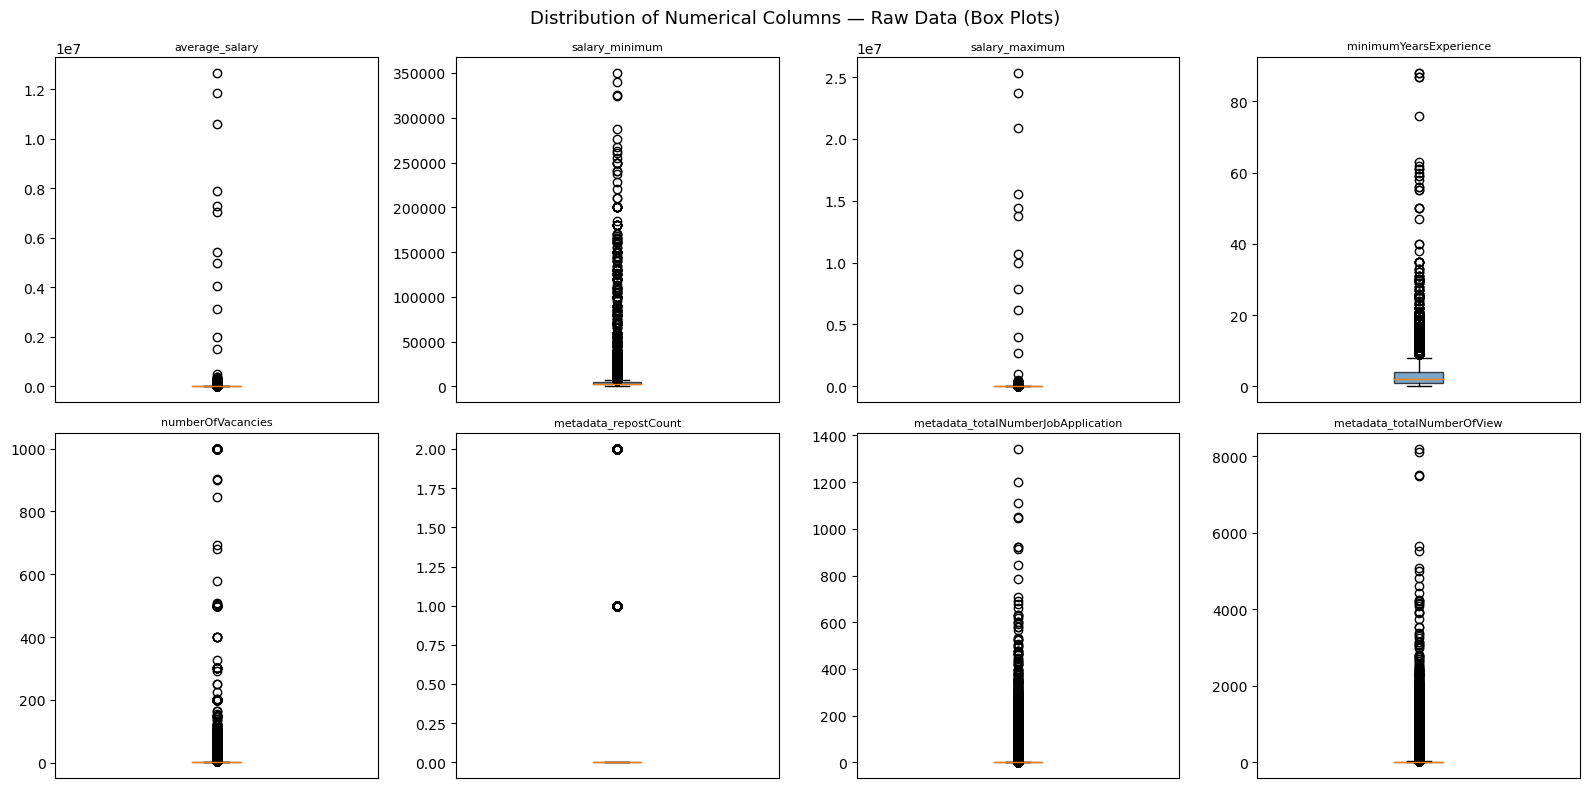

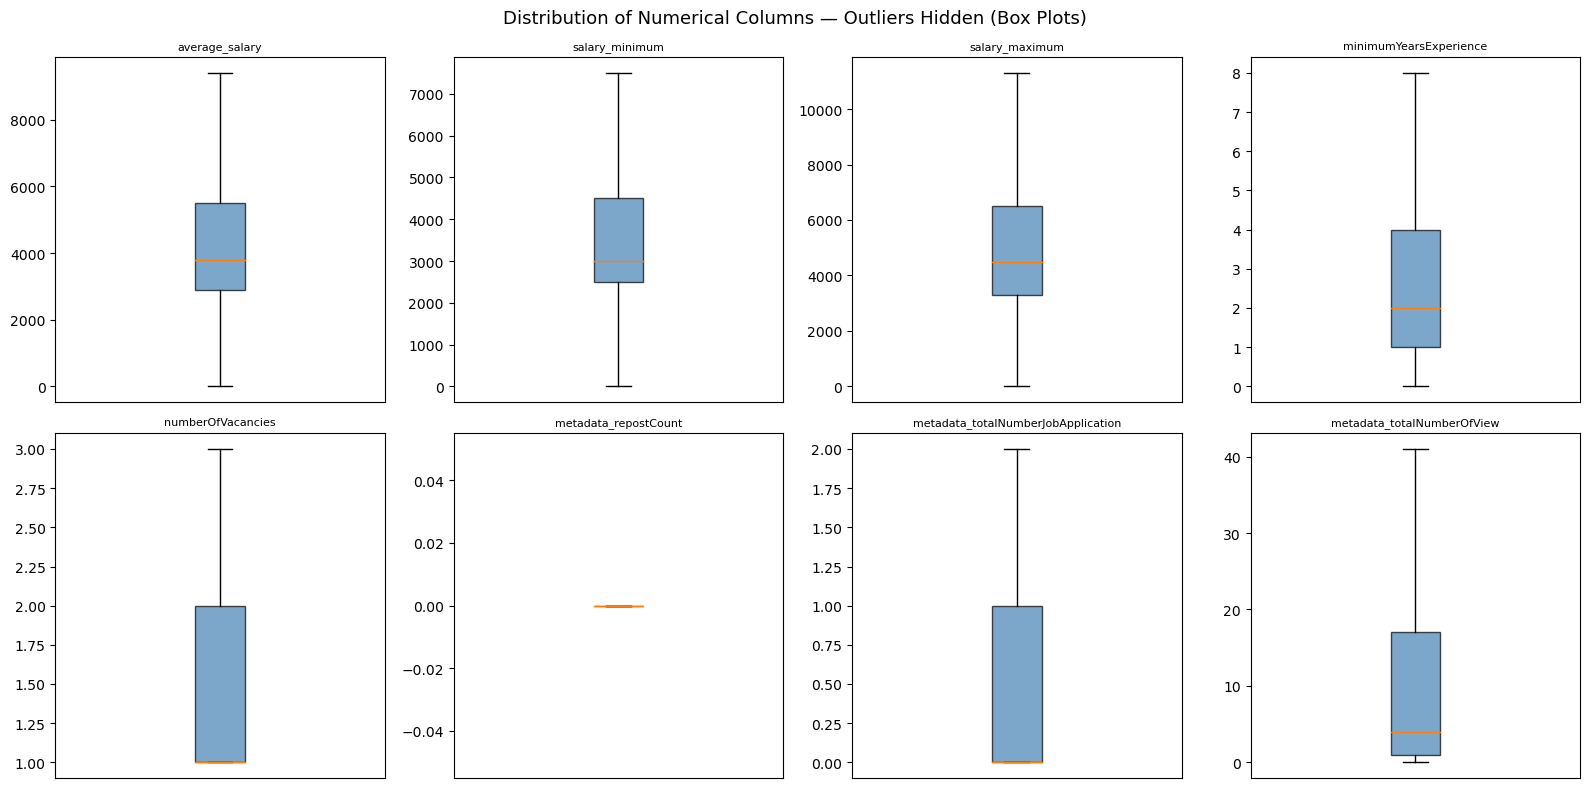

       average_salary  salary_minimum  salary_maximum  minimumYearsExperience  \
count    1.044597e+06    1.044597e+06    1.044597e+06            1.044597e+06   
mean     4.787654e+03    3.829878e+03    5.745429e+03            2.790185e+00   
std      2.552497e+04    3.169443e+03    5.027833e+04            2.536057e+00   
min      1.000000e+00    1.000000e+00    1.000000e+00            0.000000e+00   
25%      2.900000e+03    2.500000e+03    3.300000e+03            1.000000e+00   
50%      3.800000e+03    3.000000e+03    4.500000e+03            2.000000e+00   
75%      5.500000e+03    4.500000e+03    6.500000e+03            4.000000e+00   
max      1.266640e+07    3.500000e+05    2.533000e+07            8.800000e+01   

       numberOfVacancies  metadata_repostCount  \
count       1.044597e+06          1.044597e+06   
mean        2.690275e+00          5.493219e-02   
std         1.126322e+01          2.827855e-01   
min         1.000000e+00          0.000000e+00   
25%         1.000000

In [4]:
# ── Step 4: Statistical summary of numerical columns ──
# Box plots to visualise distributions and identify outliers

num_cols = ['average_salary', 'salary_minimum', 'salary_maximum',
            'minimumYearsExperience', 'numberOfVacancies',
            'metadata_repostCount', 'metadata_totalNumberJobApplication',
            'metadata_totalNumberOfView']

# Raw box plots — shows how extreme the outliers are
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xticks([])
plt.suptitle('Distribution of Numerical Columns — Raw Data (Box Plots)', fontsize=13)
plt.tight_layout()
plt.show()

# Without outliers — shows the true distribution
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7),
                    showfliers=False)
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xticks([])
plt.suptitle('Distribution of Numerical Columns — Outliers Hidden (Box Plots)', fontsize=13)
plt.tight_layout()
plt.show()

print(df[num_cols].describe())

In [5]:
# ── Step 5: Distribution of categorical columns ──
cat_cols = ['employmentTypes', 'positionLevels', 'status_jobStatus']

for col in cat_cols:
    print(f'\n── {col} ──')
    print(f'Unique values: {df[col].nunique()}')
    print(df[col].value_counts(dropna=False).head(10))


── employmentTypes ──
Unique values: 8
Permanent                458139
Full Time                393352
Contract                 139182
Part Time                 25431
Temporary                 18241
Internship/Attachment      6959
Freelance                  2139
Flexi-work                 1154
Name: employmentTypes, dtype: int64

── positionLevels ──
Unique values: 9
Executive            253701
Junior Executive     167656
Non-executive        131608
Fresh/entry level    118661
Professional         112208
Manager              110122
Senior Executive     100459
Middle Management     27375
Senior Management     22807
Name: positionLevels, dtype: int64

── status_jobStatus ──
Unique values: 3
Open       902614
Closed     119701
Re-open     22282
Name: status_jobStatus, dtype: int64


Data Cleaning

In [6]:
# ── Data Cleaning ──

# Step 1: Filter salary outliers (instructor cheat sheet)
# Lower bound: average_salary > 500
# Upper bound: 99th percentile (data-driven, not arbitrary)
# Additional: salary_minimum > 100 to remove placeholder values
p99 = np.percentile(df['average_salary'].dropna(), 99)
print(f'99th percentile of average_salary: ${p99:,.0f}')

before = len(df)
df_clean = df[
    (df['average_salary'] > 500) &
    (df['average_salary'] <= p99) &
    (df['salary_minimum'] > 100)
].copy()
print(f'Rows after salary filter: {len(df_clean):,}')
print(f'Removed: {before - len(df_clean):,} rows ({(before - len(df_clean))/before*100:.1f}%)')

99th percentile of average_salary: $16,750
Rows after salary filter: 1,025,660
Removed: 18,937 rows (1.8%)


In [7]:
# Step 2: Filter experience outliers
# Values > 20 years treated as data entry errors (88 years found in EDA)
before = len(df_clean)
df_clean = df_clean[df_clean['minimumYearsExperience'] <= 20].copy()
print(f'Rows after experience filter: {len(df_clean):,}')
print(f'Removed: {before - len(df_clean):,} rows')

Rows after experience filter: 1,025,441
Removed: 219 rows


In [8]:
# Step 3: Parse categories
# categories column is a JSON string — use regex to extract category labels

def extract_all_categories(cat_str):
    if pd.isna(cat_str):
        return []
    return re.findall(r'"category"\s*:\s*"([^"]+)"', str(cat_str))

def extract_first_category(cat_str):
    cats = extract_all_categories(cat_str)
    return cats[0] if cats else np.nan

# Add primary_category to df_clean (first category only)
df_clean['primary_category'] = df_clean['categories'].apply(extract_first_category)

# Create exploded version (one row per category per job)
# Used for accurate category-level analysis
df_exploded = df_clean.copy()
df_exploded['all_categories'] = df_exploded['categories'].apply(extract_all_categories)
df_exploded = df_exploded.explode('all_categories').rename(
    columns={'all_categories': 'category'})
df_exploded = df_exploded.dropna(subset=['category'])

print(f'df_clean rows:    {len(df_clean):,}')
print(f'df_exploded rows: {len(df_exploded):,}')
print(f'Unique categories: {df_exploded["category"].nunique()}')

df_clean rows:    1,025,441
df_exploded rows: 1,737,702
Unique categories: 43


Deduplication Strategy — Composite Key + repostCount Verification
The Problem
The dataset contains re-posted jobs. When a job is re-posted, the platform assigns it a brand new metadata_jobPostId, so the instructor's suggested method of drop_duplicates(subset='metadata_jobPostId') cannot catch these duplicates — every re-post looks like a unique job.
Our Approach: Two-Layer Verification
We use two conditions together to identify a confirmed re-post:
Layer 1 — Composite Key
We define a job's identity as the combination of three fields:

postedCompany_name — who posted it
title (lowercased and stripped) — what the job is
metadata_originalPostingDate — when it was originally posted

If two rows share the same composite key, they are candidates for being the same job re-posted.
Layer 2 — repostCount Verification
Within each group of rows that share the same composite key, we check whether the metadata_repostCount values are all distinct (e.g. 0, 1, 2).

If the values are all distinct and incrementing → this is a confirmed re-post sequence. The platform increments repostCount each time the same job is re-posted. We keep only the row with the lowest repostCount (the original posting) and remove the rest.
If the values are not all distinct (e.g. two rows both have repostCount = 1) → these are likely genuine separate vacancies posted by the same company on the same day for the same role. We keep all of them.

Why Two Layers?
Using composite key alone risks over-deduplication. For example, a restaurant that genuinely needs to hire three cooks on the same day would post three identical-looking rows — same company, same title, same date. Composite key alone would wrongly treat these as duplicates. The repostCount check catches this: if all three rows have repostCount = 0, they are not a re-post sequence and we keep all three.
Result
This approach removed only 123 rows (0.01%), far fewer than composite key alone (~48,000 rows). This gives us confidence that we are removing only confirmed re-posts, not genuine multi-vacancy postings.

In [9]:
# Step 4: Deduplicate using composite key + repostCount verification
df_clean['dedup_key'] = (
    df_clean['postedCompany_name'].fillna('') + '|' +
    df_clean['title'].str.lower().str.strip().fillna('') + '|' +
    df_clean['metadata_originalPostingDate'].astype(str)
)

# Within each composite key group, find groups where repostCount values are all distinct
# (i.e. nunique == count) = confirmed repost sequence
group_stats = df_clean.groupby('dedup_key')['metadata_repostCount'].agg(
    count='count', nunique='nunique'
).reset_index()

# Repost groups: all values distinct AND more than 1 row
repost_keys = group_stats[
    (group_stats['count'] > 1) & 
    (group_stats['count'] == group_stats['nunique'])
]['dedup_key']

# For repost groups: keep only the row with minimum repostCount
repost_df = df_clean[df_clean['dedup_key'].isin(repost_keys)]
repost_keep = repost_df.loc[repost_df.groupby('dedup_key')['metadata_repostCount'].idxmin()]

# For non-repost groups: keep all rows
non_repost_df = df_clean[~df_clean['dedup_key'].isin(repost_keys)]

df_dedup = pd.concat([non_repost_df, repost_keep]).reset_index(drop=True)

print(f'df_clean rows: {len(df_clean):,}')
print(f'df_dedup rows: {len(df_dedup):,}')
print(f'Removed: {len(df_clean) - len(df_dedup):,} rows ({(len(df_clean)-len(df_dedup))/len(df_clean)*100:.1f}%)')

df_clean rows: 1,025,441
df_dedup rows: 1,025,318
Removed: 123 rows (0.0%)


In [14]:
# ── Step 5: Create derived columns ──

# year_month for trend analysis
df_dedup['year_month'] = df_dedup['metadata_originalPostingDate'].dt.to_period('M')
df_clean['year_month'] = df_clean['metadata_originalPostingDate'].dt.to_period('M')

# Exploded version based on df_dedup (one row per category per job)
df_exploded = df_dedup.copy()
df_exploded['all_categories'] = df_exploded['categories'].apply(extract_all_categories)
df_exploded = df_exploded.explode('all_categories').rename(
    columns={'all_categories': 'category'})
df_exploded = df_exploded.dropna(subset=['category'])

# Target industry filter
TARGET_CATS = ['Information Technology', 'Healthcare / Pharmaceutical', 'Banking and Finance']
df_target = df_exploded[df_exploded['category'].isin(TARGET_CATS)].copy()

print(f'df_dedup rows:    {len(df_dedup):,}')
print(f'df_exploded rows: {len(df_exploded):,}')
print(f'df_target rows:   {len(df_target):,}')

df_dedup rows:    1,025,318
df_exploded rows: 1,737,434
df_target rows:   247,731
